# Face Detection with Haar Cascades

In [2]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
%matplotlib inline

## Images

In [3]:
model = cv2.imread('model.jpg',0)
withglass = cv2.imread('glass.jpg',0)
group = cv2.imread('group.jpg',0)

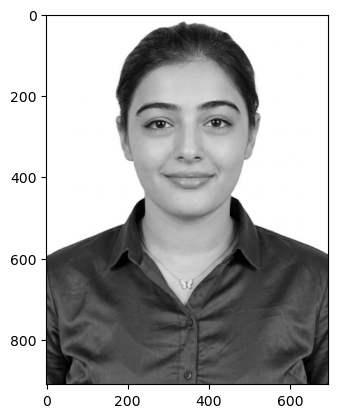

In [4]:
plt.imshow(model,cmap='gray')
plt.show()

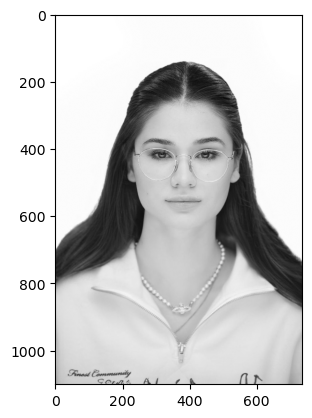

In [5]:
plt.imshow(withglass,cmap='gray')
plt.show()

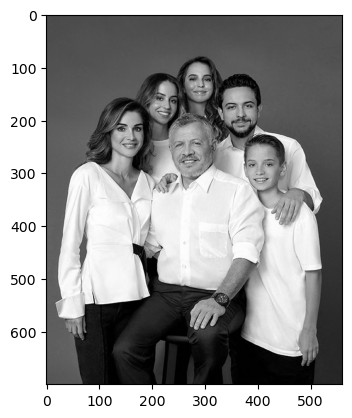

In [6]:
plt.imshow(group,cmap='gray')
plt.show()

## Cascade Files

OpenCV comes with these pre-trained cascade files, we've relocated the .xml files for you in our own DATA folder.

## Face Detection

In [7]:
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

In [8]:
def detect_face(img):
    
  
    face_img = img.copy()
  
    face_rects = face_cascade.detectMultiScale(face_img) 
    
    for (x,y,w,h) in face_rects: 
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,255,255), 10) 
        
    return face_img
    

In [9]:
result = detect_face(withglass)

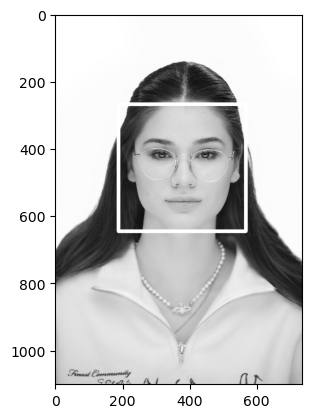

In [10]:
plt.imshow(result,cmap='gray')
plt.show()

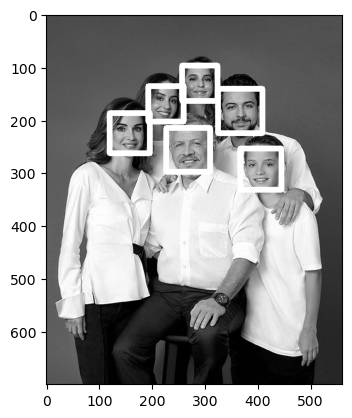

In [11]:
result = detect_face(group)
plt.imshow(result,cmap='gray')
plt.show()

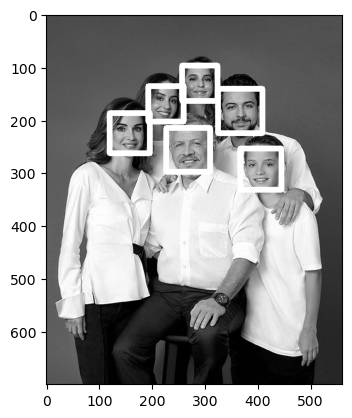

In [12]:
# Gets errors!
result = detect_face(group)
plt.imshow(result,cmap='gray')
plt.show()

In [13]:
def adj_detect_face(img):
    
    face_img = img.copy()
  
    face_rects = face_cascade.detectMultiScale(face_img,scaleFactor=1.2, minNeighbors=5) 
    
    for (x,y,w,h) in face_rects: 
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,255,255), 10) 
        
    return face_img
    

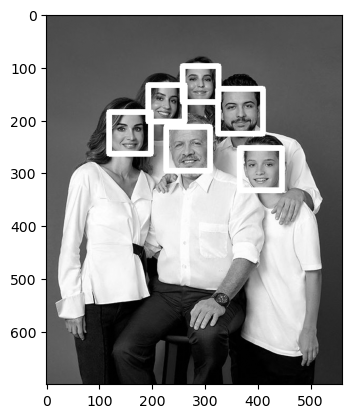

In [14]:
# Doesn't detect the side face.
result = adj_detect_face(group)
plt.imshow(result,cmap='gray')
plt.show()

## Eye Cascade File

In [15]:
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')

In [27]:
def detect_eyes(img):
    
    face_img = img.copy()
  
    eyes = eye_cascade.detectMultiScale(face_img) 
    
    
    for (x,y,w,h) in eyes: 
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,255,255), 10) 
        
    return face_img
    

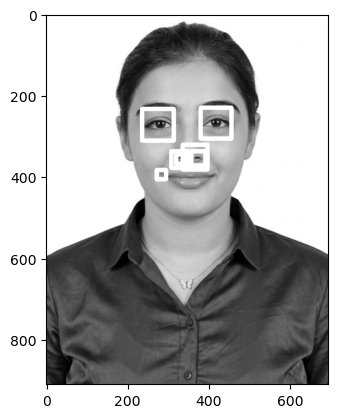

In [28]:
result = detect_eyes(model)
plt.imshow(result,cmap='gray')
plt.show()

In [29]:
eyes = eye_cascade.detectMultiScale(withglass) 

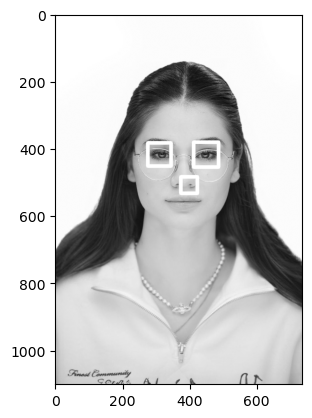

In [30]:
# White around the pupils is not distinct enough to detect Denis' eyes here!
result = detect_eyes(withglass)
plt.imshow(result,cmap='gray')
plt.show()

## Conjunction with Video

In [ ]:
from IPython.display import clear_output, display
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

In [ ]:
def new_detect(gray, frame):
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
        roi_gray = gray[y:y + h, x:x + w]
        roi_color = frame[y:y + h, x:x + w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)
    return frame

In [ ]:
video_capture = cv2.VideoCapture(0)
captured_frame = None   

while True:
    ret, frame = video_capture.read()
    if not ret:
        print("No frame captured from camera.")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    canvas = new_detect(gray, frame)
    clear_output(wait=True)
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Video - Face & Eye Detection")
    display(plt.gcf())
    captured_frame = canvas.copy()  
    break

In [ ]:
video_capture.release()
if captured_frame is not None and captured_frame.size > 0:
    cv2.imwrite('captured_face_eye.png', captured_frame)
    captured_image = cv2.imread('captured_face_eye.png', cv2.IMREAD_GRAYSCALE)
    plt.imshow(captured_image, cmap='gray')
    plt.title('Captured Face with Eye Detection')
    plt.axis('off')
    plt.show()
else:
    print("No valid frame to save.")